# Tabellarische Quellen → gemeinsame CSV mit Chandra OCR 2

Dieses Notebook verarbeitet **alle Bilder in `data/02_abgabelisten`** und führt
die erkannten Tabellen zu einer gemeinsamen Tabelle zusammen:

**Faksimiles → Chandra OCR 2 je Scan → Tabellen parsen → gemeinsame CSV**

Es ist für einen **JupyterHub** gedacht:

- kein Root-Zugriff nötig
- kein CLI-Aufruf
- kein Crop
- Cache nur in einem **beschreibbaren Verzeichnis**

## 0. Installation

Im **gleichen Jupyter-Kernel**:

```python
%pip install -U "chandra-ocr[hf]" pillow lxml pandas xlsxwriter
```

Falls Triton später meldet, dass kein C-Compiler vorhanden ist und euer Hub Conda-Pakete
im Environment erlaubt:

```python
%conda install -y -c conda-forge gcc_linux-64 gxx_linux-64
```

Danach den Kernel neu starten.

Chandra benötigt für das Modell grob **11 GB Download** plus etwas Reserve.
Der Cache-Pfad wird deshalb im nächsten Schritt geprüft.


In [1]:
%pip install -U "chandra-ocr[hf]" pillow lxml pandas xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 80.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 83.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 86.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 51.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 82.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 75.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 81.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 61.5 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 59.7 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 87.1 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 83.4 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 86.9 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━

In [2]:
%conda install -y -c conda-forge gcc_linux-64 gxx_linux-64

Retrieving notices: done
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - gcc_linux-64
    - gxx_linux-64


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    binutils_impl_linux-64-2.45.1|default_hfdba357_102         3.5 MB  conda-forge
    binutils_linux-64-2.45.1   |default_h4852527_102          35 KB  conda-forge
    ca-certificates-2026.7.22  |       hbd8a1cb_0         129 KB  conda-forge
    certifi-2026.7.22          |     pyhd8ed1ab_0         134 KB  conda-forge
    gcc_impl_linux-64-15.2.0   |      he0086c7_19        77.4 MB  conda-forge
    gcc_linux-64-15.2.0        |      h7be306e_28  

## 1. Beschreibbaren Hugging-Face-Cache wählen

Am saubersten ist es, auf dem Hub **vorher einen Pfad mit genügend Platz** zu setzen:

```python
import os
os.environ["HF_CACHE_DIR"] = "/pfad/zu/eurem/beschreibbaren/modellspeicher"
```

Wenn `HF_CACHE_DIR` nicht gesetzt ist, verwendet das Notebook:

```text
./.hf-cache
```

also einen Ordner im aktuellen Arbeitsverzeichnis.

Das Notebook prüft:

- ist der Pfad beschreibbar?
- wie viel Platz ist dort frei?
- reichen mindestens 14 GB Reserve?


In [3]:
# Diese Zelle MUSS vor transformers / huggingface_hub ausgeführt werden.
import os
import shutil
from pathlib import Path

MIN_FREE_GB = 14

cache_from_env = os.environ.get("HF_CACHE_DIR")

if cache_from_env:
    HF_CACHE = Path(cache_from_env).expanduser()
else:
    HF_CACHE = Path.cwd() / ".hf-cache"

HF_CACHE.mkdir(parents=True, exist_ok=True)

# Schreibtest
test_file = HF_CACHE / ".write_test"
try:
    test_file.write_text("ok", encoding="utf-8")
    test_file.unlink()
except OSError as exc:
    raise RuntimeError(
        f"Cache-Verzeichnis ist nicht beschreibbar: {HF_CACHE}\n"
        "Setze HF_CACHE_DIR auf einen beschreibbaren Pfad."
    ) from exc

usage = shutil.disk_usage(HF_CACHE)
free_gb = usage.free / (1024**3)

print("Arbeitsverzeichnis:", Path.cwd())
print("HF-Cache:", HF_CACHE)
print(f"Freier Platz: {free_gb:.1f} GB")

if free_gb < MIN_FREE_GB:
    raise RuntimeError(
        f"Nur {free_gb:.1f} GB frei in {HF_CACHE}. "
        f"Für Chandra sollten mindestens {MIN_FREE_GB} GB frei sein.\n\n"
        "Setze vor dieser Zelle z. B.:\n"
        'os.environ["HF_CACHE_DIR"] = "/beschreibbarer/pfad/mit/genug/platz"'
    )

os.environ["HF_HOME"] = str(HF_CACHE)
os.environ["HF_HUB_CACHE"] = str(HF_CACHE / "hub")

print("Cache-Konfiguration OK.")

Arbeitsverzeichnis: /home/jovyan/work/ki_in_kleinen_archiven
HF-Cache: /home/jovyan/work/ki_in_kleinen_archiven/.hf-cache
Freier Platz: 147.5 GB
Cache-Konfiguration OK.


## 2. Compiler-Preflight

Triton kompiliert beim ersten Lauf kleine CUDA-Hilfsmodule.
Dafür muss im Environment ein C-Compiler verfügbar sein.


In [4]:
import os
import shutil

cc = (
    shutil.which("gcc")
    or shutil.which("cc")
    or shutil.which("x86_64-conda-linux-gnu-cc")
)

cxx = (
    shutil.which("g++")
    or shutil.which("c++")
    or shutil.which("x86_64-conda-linux-gnu-c++")
)

if cc is None:
    raise RuntimeError(
        "Kein C-Compiler im Jupyter-Environment gefunden.\n"
        "Falls auf eurem Hub erlaubt:\n"
        "%conda install -y -c conda-forge gcc_linux-64 gxx_linux-64\n"
        "danach Kernel neu starten."
    )

os.environ["CC"] = cc
if cxx:
    os.environ["CXX"] = cxx

print("CC:", os.environ["CC"])
print("CXX:", os.environ.get("CXX", "(nicht gefunden)"))

CC: /opt/conda/bin/x86_64-conda-linux-gnu-cc
CXX: /opt/conda/bin/x86_64-conda-linux-gnu-c++


## 3. Scans finden und Vorschau anzeigen

Lege alle Scans mit demselben Tabellenaufbau in `data/02_abgabelisten`, relativ
zum Notebook. Aktuell sind das `0002.jpg` und `0003.jpg`.

JPG/JPEG, PNG, TIFF, BMP und WebP werden berücksichtigt, auch mit großgeschriebener
Dateiendung. Die Verarbeitung erfolgt nach Dateinamen sortiert.
Die verkleinerten Vorschauen dienen nur der Anzeige; Chandra erhält die vollständigen Bilder.

Gefundene Scans: 2
Modell: datalab-to/chandra-ocr-2
0002.jpg: 3504 × 5250 px


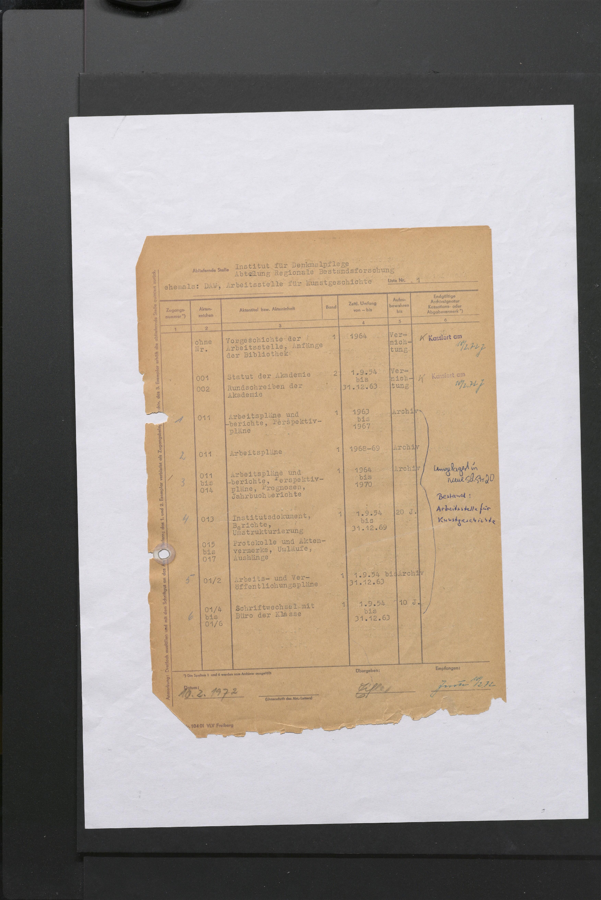

0003.jpg: 3504 × 5250 px


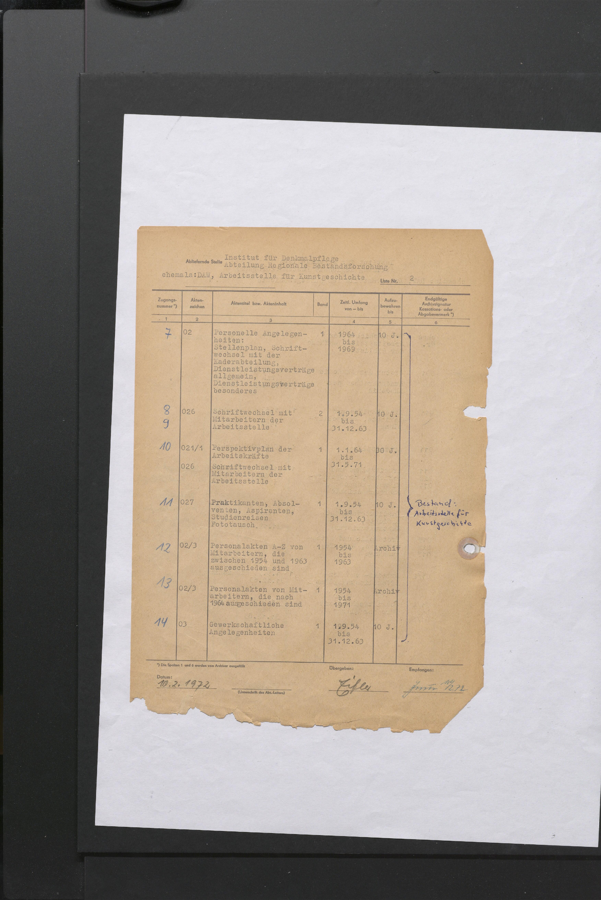

In [5]:
from pathlib import Path

from IPython.display import Markdown, display
from PIL import Image

IMAGE_DIR = Path("data/02_abgabelisten")
OUTPUT_DIR = Path("output")
CSV_PATH = OUTPUT_DIR / "abgabelisten_gesamt.csv"
MODEL_ID = "datalab-to/chandra-ocr-2"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".webp"}

if not IMAGE_DIR.is_dir():
    raise FileNotFoundError(f"Bildverzeichnis nicht gefunden: {IMAGE_DIR.resolve()}")

image_paths = sorted(
    (path for path in IMAGE_DIR.iterdir()
     if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS),
    key=lambda path: path.name,
)
if not image_paths:
    raise FileNotFoundError(f"Keine Bilddateien gefunden: {IMAGE_DIR.resolve()}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Gefundene Scans: {len(image_paths)}")
print(f"Modell: {MODEL_ID}")
for image_path in image_paths:
    with Image.open(image_path) as scan:
        print(f"{image_path.name}: {scan.width} × {scan.height} px")
        preview = scan.convert("RGB")
        preview.thumbnail((700, 900))
        display(preview)

## 4. Chandra einmal laden

Das Modell wird direkt aus Python geladen und für alle Scans wiederverwendet.

In [6]:
import torch
from chandra.model.hf import generate_hf
from chandra.model.schema import BatchInputItem
from chandra.output import parse_markdown
from transformers import AutoModelForImageTextToText, AutoProcessor

dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map="auto",
)

processor = AutoProcessor.from_pretrained(MODEL_ID)
processor.tokenizer.padding_side = "left"

model.processor = processor
model.eval()

print("CUDA verfügbar:", torch.cuda.is_available())
print("Datentyp:", dtype)
print("Chandra geladen.")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/724 [00:00<?, ?it/s]

CUDA verfügbar: True
Datentyp: torch.bfloat16
Chandra geladen.


## 5. Alle Scans analysieren

Jedes vollständige Bild wird nacheinander mit `ocr_layout` verarbeitet.
So muss immer nur ein Scan zugleich im Modell verarbeitet werden.
Die OCR-Ausgaben werden je Bild als `.raw.txt` und `.md` in `output` gespeichert,
damit sich die spätere gemeinsame Tabelle mit den einzelnen Scans vergleichen lässt.

In [7]:
ocr_results = []

for index, image_path in enumerate(image_paths, start=1):
    print(f"[{index}/{len(image_paths)}] Analysiere {image_path.name} …")
    with Image.open(image_path) as scan:
        image = scan.convert("RGB")

    try:
        batch = [BatchInputItem(image=image, prompt_type="ocr_layout")]
        with torch.inference_mode():
            result = generate_hf(batch, model)[0]
        raw_output = result.raw
        markdown = parse_markdown(raw_output)
    except Exception as exc:
        raise RuntimeError(f"OCR fehlgeschlagen für {image_path.name}") from exc
    finally:
        image.close()

    (OUTPUT_DIR / f"{image_path.name}.raw.txt").write_text(raw_output, encoding="utf-8")
    (OUTPUT_DIR / f"{image_path.name}.md").write_text(markdown, encoding="utf-8")
    ocr_results.append({
        "source": image_path.name,
        "raw_output": raw_output,
        "markdown": markdown,
    })

    display(Markdown(f"### {image_path.name}"))
    display(Markdown(markdown))

print(f"OCR abgeschlossen: {len(ocr_results)} Scans.")

[1/2] Analysiere 0002.jpg …


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.
[transformers] `causal_conv1d_update` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `fused_recurrent_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-atten

### 0002.jpg

Anmerkung: Dreifach ausfüllen und mit dem Schrägstrich an das Abgabevermerk anheften; das 1. und 2. Exemplar verbleibt als Zugangsbeleg im Archiv; das 3. Exemplar erhält die abliefernde Stelle quittiert zurück.

Abliefernde Stelle: Institut für Denkmalpflege  
Abteilung Regionale Bestandsforschung  
ehemals: DAW, Arbeitsstelle für Kunstgeschichte

Liste Nr. 1

<table border="1">
<thead>
<tr>
<th>Zugangsnummer *)</th>
<th>Aktenzeichen</th>
<th>Akzentitel bzw. Akteninhalt</th>
<th>Band</th>
<th>Zeittl. Umfang von - bis</th>
<th>Aufzubewahren bis</th>
<th>Endgültige Archivsignatur Kassations- oder Abgabevermerk *)</th>
</tr>
<tr>
<th>1</th>
<th>2</th>
<th>3</th>
<th></th>
<th>4</th>
<th>5</th>
<th>6</th>
</tr>
</thead>
<tbody>
<tr>
<td></td>
<td>ohne Nr.</td>
<td>Vorgeschichte der Arbeitsstelle, Anfänge der Bibliothek</td>
<td>1</td>
<td>1964</td>
<td>Ver-nich-tung</td>
<td>K Kassiert am 10.2.72</td>
</tr>
<tr>
<td></td>
<td>001</td>
<td>Statut der Akademie</td>
<td>2</td>
<td>1.9.54 bis</td>
<td>Ver-nich-tung</td>
<td>K Kassiert am 10.2.72</td>
</tr>
<tr>
<td></td>
<td>002</td>
<td>Rundschreiben der Akademie</td>
<td></td>
<td>31.12.63</td>
<td></td>
<td></td>
</tr>
<tr>
<td>1</td>
<td>011</td>
<td>Arbeitspläne und -berichte, Perspektiv-pläne</td>
<td>1</td>
<td>1963 bis 1967</td>
<td>Archiv</td>
<td></td>
</tr>
<tr>
<td>2</td>
<td>011</td>
<td>Arbeitspläne</td>
<td>1</td>
<td>1968-69</td>
<td>Archiv</td>
<td></td>
</tr>
<tr>
<td>3</td>
<td>011 bis 014</td>
<td>Arbeitspläne und -berichte, Perspektiv-pläne, Prognosen, Jahrbuchberichte</td>
<td>1</td>
<td>1964 bis 1970</td>
<td>Archiv</td>
<td>Umschlagged in neue Bd. Str. 20</td>
</tr>
<tr>
<td>4</td>
<td>013</td>
<td>Institutsdokument, Berichte, Umstrukturierung</td>
<td>1</td>
<td>1.9.54 bis 31.12.69</td>
<td>20 J.</td>
<td>Bestand: Arbeitsstelle für Kunstgeschichte</td>
</tr>
<tr>
<td></td>
<td>015 bis 017</td>
<td>Protokolle und Aktenvermerke, Umläufe, Aushänge</td>
<td></td>
<td></td>
<td></td>
<td></td>
</tr>
<tr>
<td>5</td>
<td>01/2</td>
<td>Arbeits- und Ver-öffentlichungspläne</td>
<td>1</td>
<td>1.9.54 bis 31.12.63</td>
<td>Archiv</td>
<td></td>
</tr>
<tr>
<td>6</td>
<td>01/4 bis 01/6</td>
<td>Schriftwechsel mit Büro der Klasse</td>
<td>1</td>
<td>1.9.54 bis 31.12.63</td>
<td>10 J.</td>
<td></td>
</tr>
</tbody>
</table>

\*) Die Spalten 1 und 6 werden vom Archivar ausgefüllt

Übergeben:

Empfangen:

Datum: 10.2.1972

(Unterschrift des Abt.-Leiters)

*[Signature]*

*[Signature]* 10.2.72

[2/2] Analysiere 0003.jpg …


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


### 0003.jpg

Abliefernde Stelle Institut für Denkmalspflege  
 Abteilung Regionale Bestandsforschung  
 ehemals: DAW, Arbeitsstelle für Kunstgeschichte

Liste Nr. 2

<table border="1">
<thead>
<tr>
<th>Zugangs-<br/>nummer *)</th>
<th>Akten-<br/>zeichen</th>
<th>Akzentitel bzw. Akteninhalt</th>
<th>Band</th>
<th>Zeitr. Umfang<br/>von - bis</th>
<th>Aufzu-<br/>bewahren<br/>bis</th>
<th>Endgültige<br/>Archivsignatur<br/>Kassations- oder<br/>Abgabevermerk *)</th>
</tr>
<tr>
<th>1</th>
<th>2</th>
<th>3</th>
<th></th>
<th>4</th>
<th>5</th>
<th>6</th>
</tr>
</thead>
<tbody>
<tr>
<td>7</td>
<td>02</td>
<td>Personelle Angelegen-<br/>heiten:<br/>Stellenplan, Schrift-<br/>wechsel mit der<br/>Kaderabteilung,<br/>Dienstleistungsverträge<br/>allgemein,<br/>Dienstleistungswertträge<br/>besonderes</td>
<td>1</td>
<td>1964<br/>bis<br/>1969</td>
<td>10 J.</td>
<td></td>
</tr>
<tr>
<td>8<br/>9</td>
<td>026</td>
<td>Schriftwechsel mit<br/>Mitarbeitern der<br/>Arbeitsstelle</td>
<td>2</td>
<td>1.9.54<br/>bis<br/>31.12.63</td>
<td>10 J.</td>
<td></td>
</tr>
<tr>
<td>10</td>
<td>021/1</td>
<td>Perspektivplan der<br/>Arbeitskräfte</td>
<td>1</td>
<td>1.1.64<br/>bis<br/>31.5.71</td>
<td>30 J.</td>
<td></td>
</tr>
<tr>
<td></td>
<td>026</td>
<td>Schriftwechsel mit<br/>Mitarbeitern der<br/>Arbeitsstelle</td>
<td></td>
<td></td>
<td></td>
<td></td>
</tr>
<tr>
<td>11</td>
<td>027</td>
<td>Praktikanten, Absol-<br/>venten, Aspiranten,<br/>Studienreisen<br/>Fototausch</td>
<td>1</td>
<td>1.9.54<br/>bis<br/>31.12.63</td>
<td>10 J.</td>
<td rowspan="2">Bestand:<br/>Arbeitsstelle für<br/>Kunstgeschichte</td>
</tr>
<tr>
<td>12</td>
<td>02/3</td>
<td>Personalakten A-Z von<br/>Mitarbeitern, die<br/>zwischen 1954 und 1963<br/>ausgeschieden sind</td>
<td>1</td>
<td>1954<br/>bis<br/>1963</td>
<td>Archiv</td>
</tr>
<tr>
<td>13</td>
<td>02/3</td>
<td>Personalakten von Mit-<br/>arbeitern, die nach<br/>1964 ausgeschieden sind</td>
<td>1</td>
<td>1954<br/>bis<br/>1971</td>
<td>Archiv</td>
<td></td>
</tr>
<tr>
<td>14</td>
<td>03</td>
<td>Gewerkschaftliche<br/>Angelegenheiten</td>
<td>1</td>
<td>1.9.54<br/>bis<br/>31.12.63</td>
<td>10 J.</td>
<td></td>
</tr>
</tbody>
</table>

\*) Die Spalten 1 und 6 werden vom Archivar ausgefüllt

Übergaben:

Empfangen:

Datum:

10.2.1972

(Unterschrift des Abt.-Leiters)

*Eifer*

*Januar 12.72*

OCR abgeschlossen: 2 Scans.


## 6. Tabellen je Scan parsen

Wir lesen HTML-Tabellen aus dem Modelloutput und fallen sonst auf Markdown-Tabellen zurück.
Wie bisher wird **je Scan die größte erkannte Tabelle** verwendet.

Die Scans haben denselben Tabellenaufbau und jeweils eine Kopfzeile. Die Überschriften
des ersten Scans gelten für alle folgenden Tabellen; die Zuordnung erfolgt nach
Spaltenposition, damit kleine OCR-Abweichungen in den Überschriften keine zusätzlichen
Spalten erzeugen. Die gedruckte Spaltennummernzeile `1, 2, 3, (Band ohne Nummer), 4, 5, 6`
wird entfernt. Zellinhalte bleiben Text, insbesondere Aktenzeichen mit führenden Nullen.

Jede Datenzeile erhält eine `Quelldatei`. Bei fehlenden Tabellen oder abweichender
Spaltenzahl bricht die Verarbeitung mit Angabe des betroffenen Scans ab.

In [8]:
import html
import re

import pandas as pd
from lxml import html as lxml_html


def clean_cell(value: str) -> str:
    value = html.unescape(value or "")
    value = re.sub(r"<br\s*/?>", "\n", value, flags=re.I)
    value = re.sub(r"[ \t]+", " ", value)
    value = re.sub(r"\s*\n\s*", "\n", value)
    return value.strip()


def parse_html_tables(text: str):
    if "<table" not in text.lower():
        return []

    root = lxml_html.fromstring(f"<div>{text}</div>")
    tables = []

    for table in root.xpath(".//table"):
        rows = []
        for tr in table.xpath(".//tr"):
            cells = tr.xpath("./th|./td")
            if cells:
                rows.append([clean_cell(c.text_content()) for c in cells])
        if rows:
            tables.append(rows)

    return tables


def split_markdown_row(line: str):
    return [clean_cell(c) for c in line.strip().strip("|").split("|")]


def is_markdown_separator(line: str):
    cells = split_markdown_row(line)
    return bool(cells) and all(
        re.fullmatch(r":?-{3,}:?", c.replace(" ", "")) for c in cells
    )


def parse_markdown_tables(text: str):
    lines = text.splitlines()
    tables = []
    i = 0

    while i < len(lines) - 1:
        if "|" in lines[i] and is_markdown_separator(lines[i + 1]):
            rows = [split_markdown_row(lines[i])]
            i += 2

            while i < len(lines) and "|" in lines[i] and lines[i].strip():
                rows.append(split_markdown_row(lines[i]))
                i += 1

            tables.append(rows)
        else:
            i += 1

    return tables




def normalize_headers(headers):
    names = []
    used = {"Quelldatei", "Prüfstatus", "Prüfnotiz"}
    for index, header in enumerate(headers, start=1):
        base = header.strip() or f"Spalte_{index}"
        name = base
        suffix = 2
        while name in used:
            name = f"{base}_{suffix}"
            suffix += 1
        used.add(name)
        names.append(name)
    return names


if [item["source"] for item in ocr_results] != [path.name for path in image_paths]:
    raise ValueError("OCR-Ergebnisse unvollständig. Bitte zuerst alle Scans in Schritt 5 verarbeiten.")

page_frames = []
common_headers = None

for item in ocr_results:
    source_name = item["source"]
    tables = parse_html_tables(item["markdown"])
    if not tables:
        tables = parse_html_tables(item["raw_output"])
    if not tables:
        tables = parse_markdown_tables(item["markdown"])
    if not tables:
        raise ValueError(f"{source_name}: Keine HTML- oder Markdown-Tabelle gefunden.")

    table = max(tables, key=lambda rows: len(rows) * max(len(row) for row in rows))
    width = max(len(row) for row in table)
    table = [row + [""] * (width - len(row)) for row in table]
    headers, rows = table[0], table[1:]

    # Diese Formularzeile bezeichnet die Spalten und ist kein Datensatz.
    column_numbers = ["1", "2", "3", "", "4", "5", "6"]
    if rows and rows[0] == column_numbers:
        rows = rows[1:]

    if common_headers is None:
        common_headers = normalize_headers(headers)
    elif width != len(common_headers):
        raise ValueError(
            f"{source_name}: {width} Spalten erkannt, erwartet sind {len(common_headers)}. "
            "Bitte den gespeicherten OCR-Output prüfen, bevor die Tabellen zusammengeführt werden."
        )
    if not rows:
        raise ValueError(f"{source_name}: Die gewählte Tabelle enthält keine Datenzeilen.")

    page_df = pd.DataFrame(rows, columns=common_headers)
    page_df.insert(0, "Quelldatei", source_name)
    page_frames.append(page_df)
    print(f"{source_name}: {len(tables)} Tabelle(n), größte Tabelle: {len(page_df)} Datenzeilen × {width} Spalten")

0002.jpg: 1 Tabelle(n), größte Tabelle: 10 Datenzeilen × 7 Spalten
0003.jpg: 1 Tabelle(n), größte Tabelle: 8 Datenzeilen × 7 Spalten


## 7. Gemeinsame Tabelle anzeigen

Die Datenzeilen aller Scans werden in Dateireihenfolge untereinander angehängt.
Gleiche Inhalte werden nicht automatisch entfernt, da sie eigenständige Einträge sein können.

In [9]:
df = pd.concat(page_frames, ignore_index=True)

print(f"Gemeinsame Tabelle: {len(df)} Datenzeilen aus {len(page_frames)} Scans")
display(df)

Gemeinsame Tabelle: 18 Datenzeilen aus 2 Scans


,Quelldatei,Zugangsnummer *),Aktenzeichen,Akzentitel bzw. Akteninhalt,Band,Zeittl. Umfang von - bis,Aufzubewahren bis,Endgültige Archivsignatur Kassations- oder Abgabevermerk *)
0,0002.jpg,,ohne Nr.,"Vorgeschichte der Arbeitsstelle, Anfänge der B...",1,1964,Ver-nich-tung,K Kassiert am 10.2.72
1,0002.jpg,,001,Statut der Akademie,2,1.9.54 bis,Ver-nich-tung,K Kassiert am 10.2.72
2,0002.jpg,,002,Rundschreiben der Akademie,,31.12.63,,
3,0002.jpg,1,011,"Arbeitspläne und -berichte, Perspektiv-pläne",1,1963 bis 1967,Archiv,
4,0002.jpg,2,011,Arbeitspläne,1,1968-69,Archiv,
5,0002.jpg,3,011 bis 014,"Arbeitspläne und -berichte, Perspektiv-pläne, ...",1,1964 bis 1970,Archiv,Umschlagged in neue Bd. Str. 20
6,0002.jpg,4,013,"Institutsdokument, Berichte, Umstrukturierung",1,1.9.54 bis 31.12.69,20 J.,Bestand: Arbeitsstelle für Kunstgeschichte
7,0002.jpg,,015 bis 017,"Protokolle und Aktenvermerke, Umläufe, Aushänge",,,,
8,0002.jpg,5,01/2,Arbeits- und Ver-öffentlichungspläne,1,1.9.54 bis 31.12.63,Archiv,
9,0002.jpg,6,01/4 bis 01/6,Schriftwechsel mit Büro der Klasse,1,1.9.54 bis 31.12.63,10 J.,


## 8. Gemeinsame CSV exportieren

Die Tabelle aus allen Scans wird als Prüfentwurf nach `output/abgabelisten_gesamt.csv`
exportiert. `Quelldatei` macht jede Zeile zum ursprünglichen Scan zurückverfolgbar;
`Prüfstatus` und `Prüfnotiz` dienen der fachlichen Nachkontrolle.

In [10]:
export_df = df.copy()
export_df["Prüfstatus"] = "offen"
export_df["Prüfnotiz"] = ""

export_df.to_csv(
    CSV_PATH,
    index=False,
    encoding="utf-8-sig",
    sep=";",
)

print(f"CSV geschrieben: {CSV_PATH.resolve()}")

CSV geschrieben: /home/jovyan/work/ki_in_kleinen_archiven/output/abgabelisten_gesamt.csv


## Ergebnis

```text
alle Bilder in data/02_abgabelisten (nach Dateinamen sortiert)
        ↓
   Chandra OCR 2 je Scan
        ↓
 größte Tabelle je Scan parsen
        ↓
 Datenzeilen mit Quelldatei zusammenführen
        ↓
 gemeinsamer DataFrame (df)
        ↓
 output/abgabelisten_gesamt.csv
        ↓
 fachliche Prüfung
```